# Static XAS 5 mmol Traditional Absorbance

Traditional absorbance using the 5 mmol run as transmitted intensity and `reference_frame.h5` as incident intensity.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')

scripts_dir = repo_root / 'analysis' / 'scripts'
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

import config as path_config
import static_xas_analysis as sxa


In [2]:
ANALYSIS_PARAMS = {
    'TRANSMITTED_RUN_NO': 58794,
    'TRANSMITTED_H5': Path(path_config.COMBINED_DIR).parent / 'xas_static' / 'run58794_static_xas.h5',
    'REFERENCE_H5': Path(path_config.COMBINED_DIR).parent / 'xas_static' / 'reference_frame.h5',
    'GMD_EDGES': np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]),
    'GMD_MIN_THRESHOLD': None,
    'GMD_MAX_THRESHOLD': 10.0,
    'VLS_INTENSITY_THRESHOLD': 1000,
    'INTENSITY_PIXEL_ROI': None,  # absolute Gotthard pixel range, e.g. (470, 620)
    'CLIP_NEGATIVE_INTENSITY': True,
    'CENTER_METHOD': 'com',
    'CENTER_HALF_WINDOW': 5,
    'CENTER_CHUNK_SIZE': 50000,
    'PROXY_PIXEL_BIN_WIDTH': 1,
    'REJECT_DOUBLE_PEAKS': False,
    'DOUBLE_PEAK_KWARGS': {
        'min_distance_px': 3,
        'max_distance_px': 17,
        'min_prom_sigma': 2.5,
        'min_height_sigma': 2.0,
        'min_rel_peak_height': 0.35,
        'min_second_ratio': 0.05,
        'min_bridge_drop': 0.015,
        'min_split_sigma': 0.75,
    },
    'PIXEL_MAP_CONFIG': {
        'source_to_grating_m': 0.85,
        'grating_to_screen_m': 0.5429,
        'incident_angle_deg': 86.78,
        'groove_density_lines_per_mm': 1200.0,
        'diffraction_order': 1,
        'magnification': 3.0,
        'pixel_pitch_m': 50e-6,
        'axis_sign': 1,
    },
    'PIXEL_MAP_CALIBRATION': {
        'pixel': 524.0,
        'energy_eV': 284.2,
    },
    'INVERSE_MAP_RANGE_EV': (260.0, 290.0),
    'INVERSE_MAP_SAMPLES': 10000,
    'YLIM': None,
}

globals().update(ANALYSIS_PARAMS)
TRANSMITTED_H5 = Path(TRANSMITTED_H5)
REFERENCE_H5 = Path(REFERENCE_H5)

print(f'transmitted file      : {TRANSMITTED_H5}')
print(f'incident file         : {REFERENCE_H5}')
print(f'gmd edges             : {GMD_EDGES}')
print(f'gmd min threshold     : {GMD_MIN_THRESHOLD}')
print(f'gmd max threshold     : {GMD_MAX_THRESHOLD}')
print(f'vls threshold         : {VLS_INTENSITY_THRESHOLD}')
print(f'intensity pixel ROI   : {INTENSITY_PIXEL_ROI}')
print(f'center method         : {CENTER_METHOD}')
print(f'proxy pixel bin width : {PROXY_PIXEL_BIN_WIDTH}')
print(f'reject double peaks   : {REJECT_DOUBLE_PEAKS}')


transmitted file      : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/run58794_static_xas.h5
incident file         : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/processed/xas_static/reference_frame.h5
gmd edges             : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
gmd min threshold     : None
gmd max threshold     : 10.0
vls threshold         : 1000
intensity pixel ROI   : None
center method         : com
proxy pixel bin width : 1
reject double peaks   : False


In [3]:
if not TRANSMITTED_H5.exists():
    raise FileNotFoundError(f'Missing transmitted static-XAS file: {TRANSMITTED_H5}')
if not REFERENCE_H5.exists():
    raise FileNotFoundError(f'Missing reference-frame static-XAS file: {REFERENCE_H5}')

trans_run = sxa.load_static_xas_run(TRANSMITTED_H5)
ref_run = sxa.load_static_xas_run(REFERENCE_H5)

print(f"transmitted run       : {trans_run.attrs.get('run_no')}")
print(f"transmitted shape     : {trans_run.vls.shape}")
print(f"transmitted E range   : {np.nanmin(trans_run.nominal_energies):.2f} .. {np.nanmax(trans_run.nominal_energies):.2f} eV")
print(f"transmitted shots     : {trans_run.stored_shots}")
print(f"reference run         : {ref_run.attrs.get('run_no')}")
print(f"reference shape       : {ref_run.vls.shape}")
print(f"reference E range     : {np.nanmin(ref_run.nominal_energies):.2f} .. {np.nanmax(ref_run.nominal_energies):.2f} eV")
print(f"reference shots       : {ref_run.stored_shots}")


transmitted run       : 58794
transmitted shape     : (31, 102720, 200)
transmitted E range   : 271.00 .. 286.00 eV
transmitted shots     : 1164240
reference run         : [58870 58871]
reference shape       : (41, 72500, 200)
reference E range     : 270.00 .. 300.00 eV
reference shots       : 2281200


In [4]:
nominal_abs_gmd = sxa.build_nominal_gmd_binned_absorbance_curve(
    trans_run,
    ref_run,
    GMD_EDGES,
    vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
    gmd_min_threshold=GMD_MIN_THRESHOLD,
    gmd_max_threshold=GMD_MAX_THRESHOLD,
    reject_double_peaks=REJECT_DOUBLE_PEAKS,
    double_peak_kwargs=DOUBLE_PEAK_KWARGS,
    intensity_pixel_roi=INTENSITY_PIXEL_ROI,
    clip_negative=CLIP_NEGATIVE_INTENSITY,
)

actual_abs_gmd = sxa.build_actual_gmd_binned_absorbance_curve(
    trans_run,
    ref_run,
    GMD_EDGES,
    PIXEL_MAP_CONFIG,
    PIXEL_MAP_CALIBRATION,
    INVERSE_MAP_RANGE_EV,
    n_samples=INVERSE_MAP_SAMPLES,
    pixel_bin_width=PROXY_PIXEL_BIN_WIDTH,
    vls_intensity_threshold=VLS_INTENSITY_THRESHOLD,
    gmd_min_threshold=GMD_MIN_THRESHOLD,
    gmd_max_threshold=GMD_MAX_THRESHOLD,
    center_method=CENTER_METHOD,
    center_half_window=CENTER_HALF_WINDOW,
    center_chunk_size=CENTER_CHUNK_SIZE,
    reject_double_peaks=REJECT_DOUBLE_PEAKS,
    double_peak_kwargs=DOUBLE_PEAK_KWARGS,
    intensity_pixel_roi=INTENSITY_PIXEL_ROI,
    clip_negative=CLIP_NEGATIVE_INTENSITY,
)

print(f"nominal common bins   : {nominal_abs_gmd.x.size}")
print(f"actual common bins    : {actual_abs_gmd.x.size}")
print(f"nominal trans shots   : {int(np.sum(nominal_abs_gmd.n_trans))}")
print(f"nominal ref shots     : {int(np.sum(nominal_abs_gmd.n_incident))}")
print(f"actual trans shots    : {int(np.sum(actual_abs_gmd.n_trans))}")
print(f"actual ref shots      : {int(np.sum(actual_abs_gmd.n_incident))}")


nominal common bins   : 19
actual common bins    : 66
nominal trans shots   : 305089
nominal ref shots     : 379544
actual trans shots    : 378020
actual ref shots      : 394796


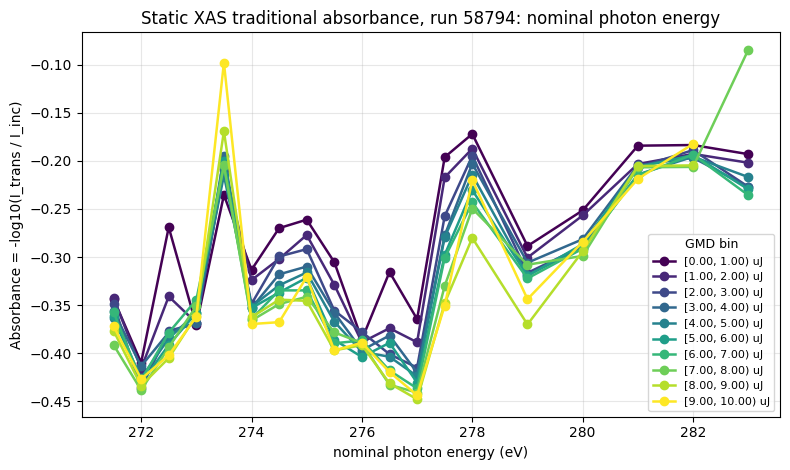

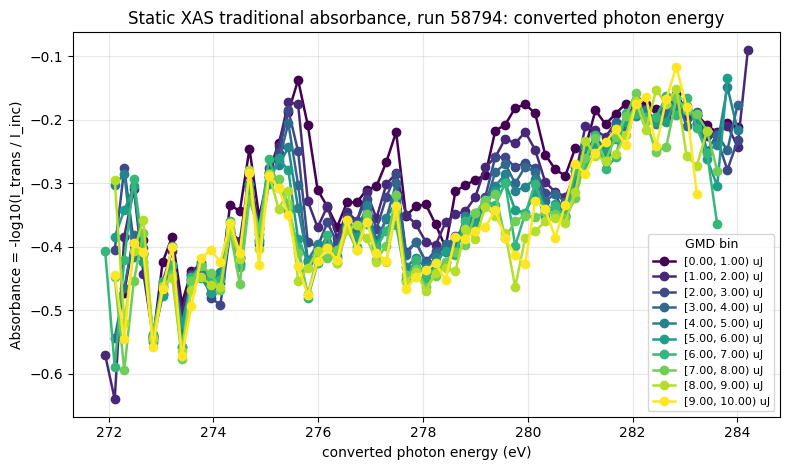

In [5]:
sxa.plot_gmd_binned_absorbance_curves(
    nominal_abs_gmd,
    title=f'Static XAS traditional absorbance, run {TRANSMITTED_RUN_NO}: nominal photon energy',
    ylim=YLIM,
)
plt.show()

sxa.plot_gmd_binned_absorbance_curves(
    actual_abs_gmd,
    title=f'Static XAS traditional absorbance, run {TRANSMITTED_RUN_NO}: converted photon energy',
    ylim=YLIM,
)
plt.show()
